<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro14YOLO/yolo9seg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# YOLO Segmentation (이미지 분할 - 객체 모양 그대로 영역(mask)을 찾음)
!pip install ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 6.0 MB/s eta 0:00:00


In [8]:
import os, cv2, numpy as np
from ultralytics import YOLO
IMG_PATH = 'image1.jpg'
OUT_DIR = 'seg_out'   # 출력 저장 폴더
os.makedirs(OUT_DIR, exist_ok=True)

im = cv2.imread(IMG_PATH)
assert im is not None, f'Image Not Found \'{IMG_PATH}\''

H, W = im.shape[:2]   # 원본 이미지 높이/너비 얻기 (마스크 리사이즈에 필요)
model = YOLO('yolo11n-seg.pt')
res = model(im)[0]
imsi = res
print(imsi.boxes)   # 탐지 박스 정보
print(imsi.masks)   # 세그멘테이션 마스크 정보
# masks.data (개별 마스크 이미지 데이터), masks.xy (객체 윤곽선 좌표), ...

cv2.imwrite(os.path.join(OUT_DIR, '00_anno.jpg'), res.plot())
# 원본 이미지 위에 바운딩 박스, 클래스 라벨, 신뢰도를 마스크로 처리
# 현재는 sanity check(기본 검증)를 함

if res.masks is None or len(res.masks.data) == 0:   # 세그 결과가 없을 때
  print('마스크 객체 없음')
  raise SystemExit

m_small = res.masks.data.cpu().numpy()    # (N, h, w) float 텐서를 numpy 배열로 변환
# print(m_small)    # 0 ~ 1 값

masks = np.stack([
    cv2.resize(m, (W, H), cv2.INTER_NEAREST) > 0.5 for m in m_small
    # cv2.INTER_NEAREST : 최근접 이웃 보간법. 이미지의 흐림 방지
], axis=0)  # mask를 모아 (N, H, W) 배열로 만듦, mask는 최종적으로 N개의 bool 스택이 됨

# seg 전 단계 : mask preview
mask_union = (masks.any(axis=0).astype(np.uint8) * 255)   # opencv에서 이미지 저장 범위가 0 ~ 255
cv2.imwrite(os.path.join(OUT_DIR, '01_mask_preview.png'), mask_union)   # 단일 마스크 흑백 이미지 저장



0: 416x640 2 persons, 195.4ms
Speed: 6.4ms preprocess, 195.4ms inference, 4.3ms postprocess per image at shape (1, 3, 416, 640)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 0.])
conf: tensor([0.8409, 0.7079])
data: tensor([[120.0181,   0.9432, 283.0374, 173.3571,   0.8409,   0.0000],
        [ 15.4300,  11.7173, 165.8862, 173.1279,   0.7079,   0.0000]])
id: None
is_track: False
orig_shape: (175, 287)
shape: torch.Size([2, 6])
xywh: tensor([[201.5277,  87.1502, 163.0193, 172.4139],
        [ 90.6581,  92.4226, 150.4562, 161.4106]])
xywhn: tensor([[0.7022, 0.4980, 0.5680, 0.9852],
        [0.3159, 0.5281, 0.5242, 0.9223]])
xyxy: tensor([[120.0181,   0.9432, 283.0374, 173.3571],
        [ 15.4300,  11.7173, 165.8862, 173.1279]])
xyxyn: tensor([[0.4182, 0.0054, 0.9862, 0.9906],
        [0.0538, 0.0670, 0.5780, 0.9893]])
ultralytics.engine.results.Masks object with attributes:

data: tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
       

True

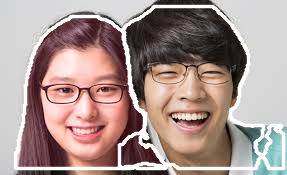

In [13]:
# 최종 세그멘테이션 : 컬러 오버레이 + 외곽선

def color(i):
  return ((37 * i) % 256, (17 * i) % 256, (91 * i) % 256)
  # 색상을 tuple로 반환 - 고유 색상, 마스크 외곽선

final = im.copy()   # 최종 합성용 캔버스
blend = np.zeros_like(im)   # im과 같은 크기의 빈 캔버스

for i, m in enumerate(masks):
  blend[m] = color(i)   # mask 영역에 고유색 채우기
  cnts, _ = cv2.findContours(   # mask 경계 추출
    (m.astype(np.uint8) * 255),
    cv2.RETR_EXTERNAL,          # 가장 바깥쪽 외곽선
    cv2.CHAIN_APPROX_SIMPLE     # 꼭지점 단순화
  )
  cv2.drawContours(final, cnts, -1, (255, 255, 255), 2, cv2.LINE_AA)  # 외곽선만 얹어 경계 시각화

# 반투명 합성
final = cv2.addWeighted(final, 1.0, blend, 0.45, 0.0)
cv2.imwrite(os.path.join(OUT_DIR, '02_final_seg.png'), final)

# vsc에서 시각화
# cv2.imshow('final seg', final)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

# colab에서 시각화
from google.colab.patches import cv2_imshow
cv2_imshow(final)